### SOLVING 0-1 KNAPSACK PROBLEM USING BEES ALGORITHM (BA) 

In [1]:
import random
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics

In [2]:
datasets = {
    "WEING1": {
        "num_constraints": 2,
        "num_items": 28,
        "values": [
            1898, 440, 22507, 270, 14148, 3100, 4650, 30800, 615, 4975,
            1160, 4225, 510, 11880, 479, 440, 490, 330, 110, 560,
            24355, 2885, 11748, 4550, 750, 3720, 1950, 10500
        ],
        "weights": [
            [45, 0, 85, 150, 65, 95, 30, 0, 170, 0, 40, 25, 20, 0, 0, 25, 0, 0, 25, 0, 165, 0, 85, 0, 0, 0, 100],
            [30, 20, 125, 5, 80, 25, 35, 73, 12, 15, 15, 40, 5, 10, 10, 12, 10, 9, 0, 20, 60, 40, 50, 36, 49, 40, 19, 150]
        ],
        "capacities": [600, 600],
        "optimal": 141278
    },

    "WEING2": {
        "num_constraints": 2,
        "num_items": 28,
        "values": [
            1898, 440, 22507, 270, 14148, 3100, 4650, 30800, 615, 4975,
            1160, 4225, 510, 11880, 479, 440, 490, 330, 110, 560,
            24355, 2885, 11748, 4550, 750, 3720, 1950, 10500
        ],
        "weights": [
            [45, 0, 85, 150, 65, 95, 30, 0, 170, 0, 40, 25, 20, 0, 0, 25, 0, 0, 25, 0, 165, 0, 85, 0, 0, 0, 100],
            [30, 20, 125, 5, 80, 25, 35, 73, 12, 15, 15, 40, 5, 10, 10, 12, 10, 9, 0, 20, 60, 40, 50, 36, 49, 40, 19, 150]
        ],
        "capacities": [500, 500],
        "optimal": 130883
    },

    "WEISH01": {
        "num_constraints": 5,
        "num_items": 30,
        "values": [
            360, 83, 59, 130, 431, 67, 230, 52, 93, 125,
            670, 892, 600, 38, 48, 147, 78, 256, 63, 17,
            120, 164, 432, 35, 92, 110, 22, 42, 50, 323
        ],
        "weights": [
            [7, 0, 30, 22, 80, 94, 11, 81, 70, 64, 59, 18, 0, 36, 3, 8, 15, 42, 9, 0, 42, 47, 52, 32, 26, 48, 55, 6, 29, 84],
            [8, 66, 98, 50, 0, 30, 0, 88, 15, 37, 26, 72, 61, 57, 17, 27, 83, 3, 9, 66, 97, 42, 2, 44, 71, 11, 25, 74, 90, 20],
            [3, 74, 88, 50, 55, 19, 0, 6, 30, 62, 17, 81, 25, 46, 67, 28, 36, 8, 1, 52, 19, 37, 27, 62, 39, 84, 16, 14, 21, 5],
            [21, 40, 0, 6, 82, 91, 43, 30, 62, 91, 10, 41, 12, 4, 80, 77, 98, 50, 78, 35, 7, 1, 96, 67, 85, 4, 23, 38, 2, 57],
            [94, 86, 80, 92, 31, 17, 65, 51, 46, 66, 44, 3, 26, 0, 39, 20, 11, 6, 55, 70, 11, 75, 82, 35, 47, 99, 5, 14, 23, 38]
        ],
        "capacities": [400, 500, 500, 600, 600],
        "optimal": 4554
    },

    "WEISH02": {
        "num_constraints": 5,
        "num_items": 30,
        "values": [
            360, 83, 59, 130, 431, 67, 230, 52, 93, 125,
            670, 892, 600, 38, 48, 147, 78, 256, 63, 17,
            120, 164, 432, 35, 92, 110, 22, 42, 50, 323
        ],
        "weights": [
            [7, 0, 30, 22, 80, 94, 11, 81, 70, 64, 59, 18, 0, 36, 3, 8, 15, 42, 9, 0, 42, 47, 52, 32, 26, 48, 55, 6, 29, 84],
            [8, 66, 98, 50, 0, 30, 0, 88, 15, 37, 26, 72, 61, 57, 17, 27, 83, 3, 9, 66, 97, 42, 2, 44, 71, 11, 25, 74, 90, 20],
            [3, 74, 88, 50, 55, 19, 0, 6, 30, 62, 17, 81, 25, 46, 67, 28, 36, 8, 1, 52, 19, 37, 27, 62, 39, 84, 16, 14, 21, 5],
            [21, 40, 0, 6, 82, 91, 43, 30, 62, 91, 10, 41, 12, 4, 80, 77, 98, 50, 78, 35, 7, 1, 96, 67, 85, 4, 23, 38, 2, 57],
            [94, 86, 80, 92, 31, 17, 65, 51, 46, 66, 44, 3, 26, 0, 39, 20, 11, 6, 55, 70, 11, 75, 82, 35, 47, 99, 5, 14, 23, 38]
        ],
        "capacities": [370, 650, 460, 980, 870],
        "optimal": 4536
    },

    "WEISH19": {
        "num_constraints": 5,
        "num_items": 70,
        "values": [
            360, 83, 59, 130, 431, 67, 230, 52, 93, 125,
            670, 892, 600, 38, 48, 147, 78, 256, 63, 17,
            120, 164, 432, 35, 92, 110, 22, 42, 50, 323,
            514, 28, 87, 73, 78, 15, 26, 78, 210, 36,
            85, 189, 274, 43, 33, 10, 19, 389, 276, 312,
            94, 68, 73, 192, 41, 163, 16, 40, 195, 138,
            73, 152, 400, 26, 14, 170, 205, 57, 369, 435
        ],
        "weights": [
            [7, 0, 30, 22, 80, 94, 11, 81, 70, 64, 59, 18, 0, 36, 3, 8, 15, 42, 9, 0, 42, 47, 52, 32, 26, 48, 55, 6, 29, 84, 2, 4, 18, 56, 7, 29, 93, 44, 71, 3, 86, 66, 31, 65, 0, 79, 20, 65, 52, 13, 48, 14, 5, 72, 14, 39, 46, 27, 11, 91, 15, 25, 0, 94, 53, 48, 27, 99, 6, 17],
            [8, 66, 98, 50, 0, 30, 0, 88, 15, 37, 26, 72, 61, 57, 17, 27, 83, 3, 9, 66, 97, 42, 2, 44, 71, 11, 25, 74, 90, 20, 0, 38, 33, 14, 9, 23, 12, 58, 6, 14, 78, 0, 12, 99, 84, 31, 16, 7, 33, 20, 5, 18, 96, 63, 31, 0, 70, 4, 66, 9, 15, 25, 2, 0, 48, 1, 40, 31, 82, 79],
            [3, 74, 88, 50, 55, 19, 0, 6, 30, 62, 17, 81, 25, 46, 67, 28, 36, 8, 1, 52, 19, 37, 27, 62, 39, 84, 16, 14, 21, 5, 60, 82, 72, 89, 16, 5, 29, 7, 80, 97, 41, 46, 15, 92, 51, 76, 57, 90, 10, 37, 25, 93, 5, 39, 0, 97, 6, 96, 2, 81, 69, 4, 32, 78, 65, 83, 62, 89, 45, 53],
            [21, 40, 0, 6, 82, 91, 43, 30, 62, 91, 10, 41, 12, 4, 80, 77, 98, 50, 78, 35, 7, 1, 96, 67, 85, 4, 23, 38, 2, 57, 4, 53, 0, 33, 2, 25, 14, 97, 87, 42, 15, 65, 19, 83, 67, 70, 80, 39, 9, 5, 41, 31, 36, 15, 30, 87, 28, 13, 40, 0, 51, 79, 75, 43, 91, 60, 24, 18, 85, 83],
            [94, 86, 80, 92, 31, 17, 65, 51, 46, 66, 44, 3, 26, 0, 39, 20, 11, 6, 55, 70, 11, 75, 82, 35, 47, 99, 5, 14, 23, 38, 94, 66, 64, 27, 77, 50, 28, 25, 61, 10, 30, 15, 12, 24, 90, 25, 39, 47, 98, 83, 56, 36, 6, 66, 89, 45, 38, 1, 18, 88, 19, 39, 20, 1, 7, 34, 68, 32, 31, 58]
        ],
        "capacities": [1200, 1920, 2330, 620, 1460],
        "optimal": 7698
    },

    "WEISH20": {
        "num_constraints": 5,
        "num_items": 70,
        "values": [
            360, 83, 59, 130, 431, 67, 230, 52, 93, 125,
            670, 892, 600, 38, 48, 147, 78, 256, 63, 17,
            120, 164, 432, 35, 92, 110, 22, 42, 50, 323,
            514, 28, 87, 73, 78, 15, 26, 78, 210, 36,
            85, 189, 274, 43, 33, 10, 19, 389, 276, 312,
            94, 68, 73, 192, 41, 163, 16, 40, 195, 138,
            73, 152, 400, 26, 14, 170, 205, 57, 369, 435
        ],
        "weights": [
            [7, 0, 30, 22, 80, 94, 11, 81, 70, 64, 59, 18, 0, 36, 3, 8, 15, 42, 9, 0, 42, 47, 52, 32, 26, 48, 55, 6, 29, 84, 2, 4, 18, 56, 7, 29, 93, 44, 71, 3, 86, 66, 31, 65, 0, 79, 20, 65, 52, 13, 48, 14, 5, 72, 14, 39, 46, 27, 11, 91, 15, 25, 0, 94, 53, 48, 27, 99, 6, 17],
            [8, 66, 98, 50, 0, 30, 0, 88, 15, 37, 26, 72, 61, 57, 17, 27, 83, 3, 9, 66, 97, 42, 2, 44, 71, 11, 25, 74, 90, 20, 0, 38, 33, 14, 9, 23, 12, 58, 6, 14, 78, 0, 12, 99, 84, 31, 16, 7, 33, 20, 5, 18, 96, 63, 31, 0, 70, 4, 66, 9, 15, 25, 2, 0, 48, 1, 40, 31, 82, 79],
            [3, 74, 88, 50, 55, 19, 0, 6, 30, 62, 17, 81, 25, 46, 67, 28, 36, 8, 1, 52, 19, 37, 27, 62, 39, 84, 16, 14, 21, 5, 60, 82, 72, 89, 16, 5, 29, 7, 80, 97, 41, 46, 15, 92, 51, 76, 57, 90, 10, 37, 25, 93, 5, 39, 0, 97, 6, 96, 2, 81, 69, 4, 32, 78, 65, 83, 62, 89, 45, 53],
            [21, 40, 0, 6, 82, 91, 43, 30, 62, 91, 10, 41, 12, 4, 80, 77, 98, 50, 78, 35, 7, 1, 96, 67, 85, 4, 23, 38, 2, 57, 4, 53, 0, 33, 2, 25, 14, 97, 87, 42, 15, 65, 19, 83, 67, 70, 80, 39, 9, 5, 41, 31, 36, 15, 30, 87, 28, 13, 40, 0, 51, 79, 75, 43, 91, 60, 24, 18, 85, 83],
            [94, 86, 80, 92, 31, 17, 65, 51, 46, 66, 44, 3, 26, 0, 39, 20, 11, 6, 55, 70, 11, 75, 82, 35, 47, 99, 5, 14, 23, 38, 94, 66, 64, 27, 77, 50, 28, 25, 61, 10, 30, 15, 12, 24, 90, 25, 39, 47, 98, 83, 56, 36, 6, 66, 89, 45, 38, 1, 18, 88, 19, 39, 20, 1, 7, 34, 68, 32, 31, 58]
        ],
        "capacities": [1320, 700, 1730, 1954, 1810],
        "optimal": 9450
    }
}

with open("mknap_2.json", "w") as f:
    json.dump(datasets, f, indent=2)


--- Running dataset: WEING1 ---

Runtime: 0.433 seconds
Best value found at iteration: 17
Run 1: Best = 141258, Iteration = 17, Runtime = 0.433s


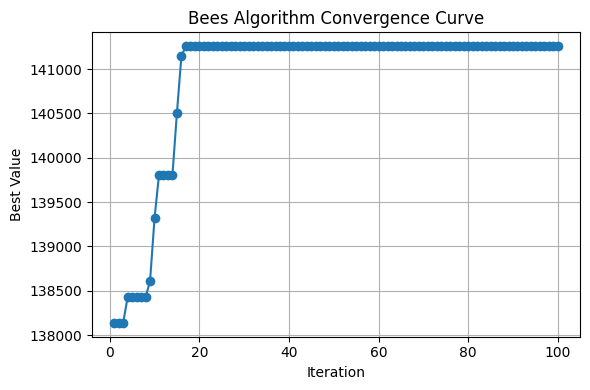


Runtime: 0.427 seconds
Best value found at iteration: 81
Run 2: Best = 141247, Iteration = 81, Runtime = 0.427s

Runtime: 0.420 seconds
Best value found at iteration: 7
Run 3: Best = 141258, Iteration = 7, Runtime = 0.420s

Runtime: 0.446 seconds
Best value found at iteration: 36
Run 4: Best = 141258, Iteration = 36, Runtime = 0.446s

Runtime: 0.454 seconds
Best value found at iteration: 80
Run 5: Best = 140618, Iteration = 80, Runtime = 0.455s

Runtime: 0.452 seconds
Best value found at iteration: 37
Run 6: Best = 141278, Iteration = 37, Runtime = 0.452s

Runtime: 0.435 seconds
Best value found at iteration: 26
Run 7: Best = 141258, Iteration = 26, Runtime = 0.435s

Runtime: 0.423 seconds
Best value found at iteration: 26
Run 8: Best = 141258, Iteration = 26, Runtime = 0.423s

Runtime: 0.425 seconds
Best value found at iteration: 76
Run 9: Best = 141278, Iteration = 76, Runtime = 0.425s

Runtime: 0.420 seconds
Best value found at iteration: 45
Run 10: Best = 141258, Iteration = 45, R

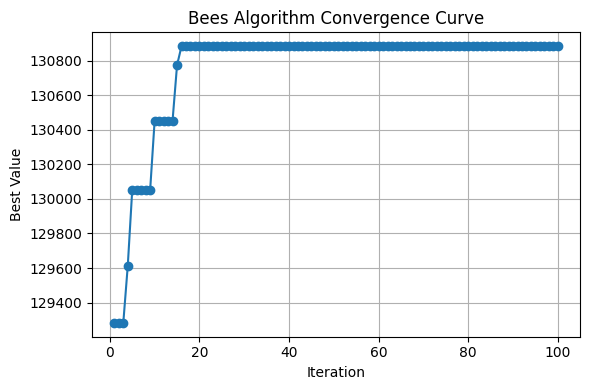


Runtime: 0.458 seconds
Best value found at iteration: 42
Run 2: Best = 130883, Iteration = 42, Runtime = 0.458s

Runtime: 0.474 seconds
Best value found at iteration: 20
Run 3: Best = 130723, Iteration = 20, Runtime = 0.474s

Runtime: 0.466 seconds
Best value found at iteration: 40
Run 4: Best = 130883, Iteration = 40, Runtime = 0.467s

Runtime: 0.465 seconds
Best value found at iteration: 7
Run 5: Best = 130883, Iteration = 7, Runtime = 0.465s

Runtime: 0.502 seconds
Best value found at iteration: 18
Run 6: Best = 130883, Iteration = 18, Runtime = 0.502s

Runtime: 0.449 seconds
Best value found at iteration: 24
Run 7: Best = 130883, Iteration = 24, Runtime = 0.449s

Runtime: 0.439 seconds
Best value found at iteration: 34
Run 8: Best = 130723, Iteration = 34, Runtime = 0.439s

Runtime: 0.455 seconds
Best value found at iteration: 61
Run 9: Best = 130773, Iteration = 61, Runtime = 0.455s

Runtime: 0.470 seconds
Best value found at iteration: 32
Run 10: Best = 130883, Iteration = 32, R

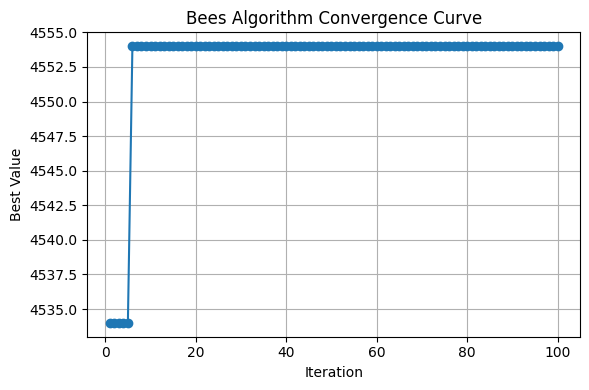


Runtime: 0.925 seconds
Best value found at iteration: 13
Run 2: Best = 4554, Iteration = 13, Runtime = 0.926s

Runtime: 0.952 seconds
Best value found at iteration: 7
Run 3: Best = 4554, Iteration = 7, Runtime = 0.952s

Runtime: 0.956 seconds
Best value found at iteration: 21
Run 4: Best = 4554, Iteration = 21, Runtime = 0.956s

Runtime: 0.952 seconds
Best value found at iteration: 11
Run 5: Best = 4554, Iteration = 11, Runtime = 0.952s

Runtime: 0.956 seconds
Best value found at iteration: 14
Run 6: Best = 4554, Iteration = 14, Runtime = 0.957s

Runtime: 0.943 seconds
Best value found at iteration: 9
Run 7: Best = 4554, Iteration = 9, Runtime = 0.943s

Runtime: 0.967 seconds
Best value found at iteration: 17
Run 8: Best = 4554, Iteration = 17, Runtime = 0.967s

Runtime: 0.932 seconds
Best value found at iteration: 12
Run 9: Best = 4554, Iteration = 12, Runtime = 0.933s

Runtime: 0.909 seconds
Best value found at iteration: 10
Run 10: Best = 4554, Iteration = 10, Runtime = 0.909s

---

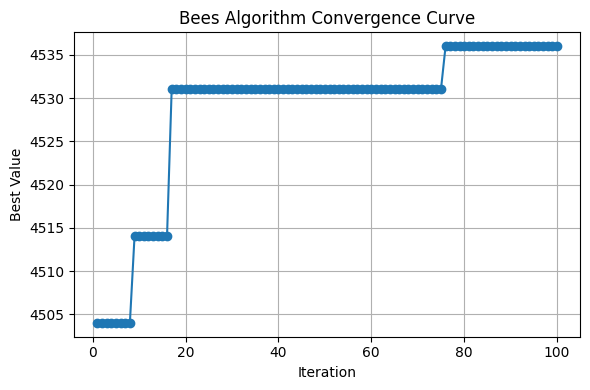


Runtime: 0.959 seconds
Best value found at iteration: 86
Run 2: Best = 4536, Iteration = 86, Runtime = 0.959s

Runtime: 0.945 seconds
Best value found at iteration: 21
Run 3: Best = 4536, Iteration = 21, Runtime = 0.945s

Runtime: 0.938 seconds
Best value found at iteration: 20
Run 4: Best = 4536, Iteration = 20, Runtime = 0.938s

Runtime: 0.960 seconds
Best value found at iteration: 18
Run 5: Best = 4536, Iteration = 18, Runtime = 0.960s

Runtime: 0.949 seconds
Best value found at iteration: 25
Run 6: Best = 4536, Iteration = 25, Runtime = 0.950s

Runtime: 0.938 seconds
Best value found at iteration: 15
Run 7: Best = 4536, Iteration = 15, Runtime = 0.939s

Runtime: 0.946 seconds
Best value found at iteration: 16
Run 8: Best = 4531, Iteration = 16, Runtime = 0.947s

Runtime: 0.962 seconds
Best value found at iteration: 24
Run 9: Best = 4531, Iteration = 24, Runtime = 0.963s

Runtime: 0.948 seconds
Best value found at iteration: 39
Run 10: Best = 4536, Iteration = 39, Runtime = 0.949s


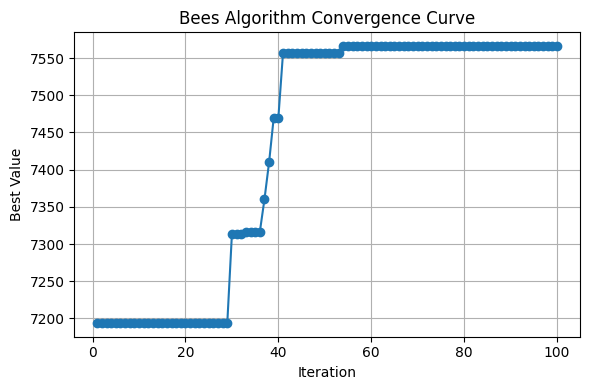


Runtime: 2.228 seconds
Best value found at iteration: 99
Run 2: Best = 7629, Iteration = 99, Runtime = 2.228s

Runtime: 2.257 seconds
Best value found at iteration: 96
Run 3: Best = 7331, Iteration = 96, Runtime = 2.258s

Runtime: 2.204 seconds
Best value found at iteration: 58
Run 4: Best = 7663, Iteration = 58, Runtime = 2.204s

Runtime: 2.238 seconds
Best value found at iteration: 56
Run 5: Best = 7371, Iteration = 56, Runtime = 2.239s

Runtime: 2.218 seconds
Best value found at iteration: 32
Run 6: Best = 7379, Iteration = 32, Runtime = 2.219s

Runtime: 2.258 seconds
Best value found at iteration: 68
Run 7: Best = 7621, Iteration = 68, Runtime = 2.258s

Runtime: 2.234 seconds
Best value found at iteration: 38
Run 8: Best = 7698, Iteration = 38, Runtime = 2.235s

Runtime: 2.210 seconds
Best value found at iteration: 87
Run 9: Best = 7449, Iteration = 87, Runtime = 2.210s

Runtime: 2.241 seconds
Best value found at iteration: 85
Run 10: Best = 7645, Iteration = 85, Runtime = 2.241s


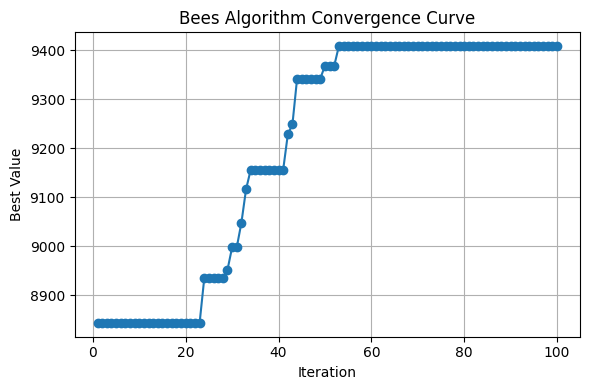


Runtime: 1.994 seconds
Best value found at iteration: 73
Run 2: Best = 9306, Iteration = 73, Runtime = 1.994s

Runtime: 2.003 seconds
Best value found at iteration: 36
Run 3: Best = 9326, Iteration = 36, Runtime = 2.003s

Runtime: 2.012 seconds
Best value found at iteration: 33
Run 4: Best = 9410, Iteration = 33, Runtime = 2.013s

Runtime: 1.954 seconds
Best value found at iteration: 61
Run 5: Best = 9382, Iteration = 61, Runtime = 1.954s

Runtime: 2.009 seconds
Best value found at iteration: 85
Run 6: Best = 9370, Iteration = 85, Runtime = 2.010s

Runtime: 1.991 seconds
Best value found at iteration: 99
Run 7: Best = 9312, Iteration = 99, Runtime = 1.992s

Runtime: 1.961 seconds
Best value found at iteration: 62
Run 8: Best = 9295, Iteration = 62, Runtime = 1.962s

Runtime: 1.993 seconds
Best value found at iteration: 82
Run 9: Best = 9323, Iteration = 82, Runtime = 1.993s

Runtime: 2.011 seconds
Best value found at iteration: 60
Run 10: Best = 9288, Iteration = 60, Runtime = 2.011s


In [3]:
class BeesAlgorithm:
  def __init__(self, values, weights, capacities, num_bees, num_onlookers, limit):

    if isinstance(weights[0], list):
      self.weights = weights
    else:
      self.weights = [weights]
    
    if isinstance(capacities, list):
      self.capacities = capacities
    else:
      self.capacities = [capacities]

    self.values = values
    self.n = len(values)
    self.m = len(self.capacities)
    self.num_bees = num_bees
    self.num_onlookers = num_onlookers
    self.limit = limit
    self.history = []

  def total_value(self, x):
    """Calculate total values of chosen items."""
    total = 0
    for i in range(self.n):
      total += self.values[i] * x[i]
    return total

  def total_weight(self, x):
    """Calculate total weights across all constraints of chosen items."""
    total = []
    for j in range(self.m):
      w = 0
      for i in range(self.n):
        w += self.weights[j][i] * x[i]
      total.append(w)
    return total

  def is_feasible(self, x):
    """Check if the solution is feasible within capacity."""
    loads = self.total_weight(x)
    for j in range(self.m):
      if loads[j] > self.capacities[j]:
        return False
    return True

  def random_solution(self):
    """Generate a random feasible solution and repair if necessary."""
    x = [random.randint(0, 1) for _ in range(self.n)]
    if not self.is_feasible(x):
      x = self.repair(x)
    return x
  
  def greedy_solution(self):
    """Generate a greedy feasible solution based on value/weight ratio."""
    ratios = [] 
    for i in range(self.n):
      w_sum = 0
      for j in range(self.m):
        w_sum += self.weights[j][i]
      if w_sum == 0:
        ratio = 0
      else:
        ratio = self.values[i] / w_sum
        ratios.append((ratio, i))
    
    # Take items from best ratio to worst, while keeping feasibility
    ratios.sort(reverse=True)
    x = [0]*self.n
    loads = [0]*self.m
    for _, i in ratios:
      # Try adding item i
      can_add = True
      for j in range(self.m):
        if loads[j] + self.weights[j][i] > self.capacities[j]:
          can_add = False
          break
      if can_add:
        x[i] = 1
        for j in range(self.m):
          loads[j] += self.weights[j][i]
    return x

  def repair(self, x):
    """Repair an infeasible solution by removing items with smallest value/weight ratio first."""
    total_w = self.total_weight(x)

    # Check if already feasible
    feasible = True
    for j in range(self.m):
      if total_w[j] > self.capacities[j]:
        feasible = False
        break
    if feasible:
      return x

    # Make a list of selected items with simple value/weight ratio
    items = []

    for i in range(self.n):
      if x[i] == 1:
        w_sum = 0
        for j in range(self.m):
          w_sum += self.weights[j][i]
        if w_sum == 0:
            ratio = 0
        else:
            ratio = self.values[i] / w_sum
        items.append((ratio, i))
    
    # Remove items with smallest ratio first
    items.sort()
    for ratio, i in items:
      total_w = self.total_weight(x)
      over = False
      for j in range(self.m):
        if total_w[j] > self.capacities[j]:
          over = True
          break
      if not over:
        break
      x[i] = 0
    return x

  def fitness(self, x, penalty=200):
    """Calculate fitness with penalty for infeasibility."""
    total_v = self.total_value(x)
    total_w = self.total_weight(x)

    over = 0
    for j in range (self.m):
      if total_w[j]> self.capacities[j]:
        over += (total_w[j] - self.capacities[j])
    
    if over == 0:
      return total_v
    else:
      return total_v - penalty * over

  def initialize_population(self):
      """Initialize population with one greedy solution and rest random."""
      population = []
      g = self.greedy_solution()
      population.append(g)
      # Fill the rest with random solutions
      for _ in range(self.num_bees - 1):
        x = self.random_solution()
        population.append(x)
      return population

  def neighbor(self, x):
    """Generate a neighbor solution by two independent random 1-bit flips."""
    
    # First random 1-bit flip
    y1 = x[:]
    i = random.randint(0, self.n - 1)
    y1[i] = 1 - y1[i]
    if not self.is_feasible(y1):
      y1 = self.repair(y1)

    # Second random 1-bit flip
    y2 = x[:]
    j = random.randint(0, self.n - 1)
    y2[j] = 1 - y2[j]
    if not self.is_feasible(y2):
      y2 = self.repair(y2)

    # Return the better of the two neighbors
    return y1 if self.fitness(y1) >= self.fitness(y2) else y2

  def employed_bee_phase(self, population, trials):
    """Each employed bee searches for a better solution near its current one."""
    for i in range(len(population)):
      y = self.neighbor(population[i])
      fit_y = self.fitness(y)
      fit_x = self.fitness(population[i])
      # If the neighbor is better or equally good, but simpler, keep it
      if fit_y > fit_x or (fit_y == fit_x and sum(y) < sum(population[i])):
        population[i] = y
        trials[i] = 0
      else:
        trials[i] += 1
    return population, trials

  def onlooker_bee_phase(self, population, trials):
    """Onlooker bees choose source bees based on fitness probabilities and search for neighbors."""

    # Calculate fitness values for all solutions
    fitness_values = [self.fitness(x) for x in population]

    # Make all fitness values non-negative (important for infeasible solutions)
    min_fit = min(fitness_values)
    if min_fit < 0:
      fitness_values = [f - min_fit +1 for f in fitness_values]
    
    total_fit = sum(fitness_values)

    # Calculate selection probabilities
    if total_fit == 0:
      probabilities = [1 / len(fitness_values)] * len(fitness_values)
    else:
      probabilities = [f / total_fit for f in fitness_values]
    
    # Onlooker bees select source bees and search for neighbors
    for _ in range(self.num_onlookers):
      r = random.random()
      running_total = 0
      for i, p in enumerate(probabilities):
        running_total += p
        if r <= running_total:
          y = self.neighbor(population[i])
          if self.fitness(y) > self.fitness(population[i]):
            population[i] = y
            trials[i] = 0
          else:
            trials[i] += 1
          break
    return population, trials

  def scout_bee_phase(self, population, trials):
    """Replace bees that haven't improved for a while with new random solutions"""
    for i in range(len(population)):
      if trials[i] >= self.limit:
        population[i] = self.random_solution()
        trials[i] = 0
    return population, trials

  def run(self, iterations):
    """Run the Bees Algorithm for a specified number of iterations."""
    start_time = datetime.datetime.now()
    population = self.initialize_population()
    trials = [0]*len(population)
    best = max(population, key=self.fitness)
    best_iteration = 0

    for t in range(iterations):
      population, trials = self.employed_bee_phase(population, trials)
      population, trials = self.onlooker_bee_phase(population, trials)
      population, trials = self.scout_bee_phase(population, trials)
      current_best=max(population, key=self.fitness)
      avg_fit = np.mean([self.fitness(x) for x in population])
      if self.fitness(current_best) > self.fitness(best):
        best = current_best
        best_iteration = t + 1

      self.history.append((t+1, self.fitness(best), avg_fit))
      #print(f"Iteration {t+1}: best value = {self.fitness(best)}")

    end_time = datetime.datetime.now()
    runtime = (end_time - start_time).total_seconds()
    print(f"\nRuntime: {runtime:.3f} seconds")
    print(f"Best value found at iteration: {best_iteration}")
    return best

  def plot_convergence(self):
    if not self.history:
      print("No convergence data to plot.")
      return
  
    iterations = [row[0] for row in self.history]
    best_values = [row[1] for row in self.history]
    plt.figure(figsize=(6, 4))
    plt.plot(iterations, best_values, marker="o", linewidth=1.5)
    plt.title("Bees Algorithm Convergence Curve")
    plt.xlabel("Iteration")
    plt.ylabel("Best Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def pad_weights(weights_2d, n):
  """Pad each weight list to length n."""
  padded = []
  for w in weights_2d:
    if len(w) < n:
      w = w + [0] * (n - len(w))  
    elif len(w) > n:
      w = w[:n]                    
    padded.append(w)
  return padded

def evaluate_all_datasets(datasets, runs):
    """Run the Bees Algorithm on all datasets and summarize the results"""
    summary = []
    for name, data in datasets.items():
        print(f"\n--- Running dataset: {name} ---")

        values = data["values"]
        weights = pad_weights(data["weights"], len(values))
        capacities = data["capacities"]
        optimal = data["optimal"]

        best_values = []
        runtimes = []
        best_iterations = []
        avg_fitnesses = []

        for seed in range(runs):
            random.seed(seed)
            algo = BeesAlgorithm(values, weights, capacities,
                                 num_bees=60, num_onlookers=25, limit=20)
            start = datetime.datetime.now()
            best_solution = algo.run(iterations=100)
            assert algo.is_feasible(best_solution), f"Infeasiible solution in {name}"
            end = datetime.datetime.now()
            runtime = (end - start).total_seconds()

            best_val = algo.total_value(best_solution)
            avg_fit = algo.history[-1][2] if algo.history else best_val
            best_iteration = max(algo.history, key=lambda x: x[1])[0]
            weight_used = algo.total_weight(best_solution)
            baseline = algo.total_value(algo.greedy_solution())

            best_values.append(best_val)
            runtimes.append(runtime)
            best_iterations.append(best_iteration)
            avg_fitnesses.append(avg_fit)

            print(f"Run {seed+1}: Best = {best_val}, Iteration = {best_iteration}, Runtime = {runtime:.3f}s")

            if seed == 0:
                algo.plot_convergence()

        best_overall = max(best_values)
        avg_best = round(statistics.mean(best_values), 2)
        std_best = round(statistics.stdev(best_values), 2)
        avg_runtime = round(statistics.mean(runtimes), 3)
        avg_iteration_best = int(round(statistics.mean(best_iterations)))
        avg_fit = round(statistics.mean(avg_fitnesses), 2)
        improvement = round(best_overall / optimal * 100, 2)
        final_best_value = algo.history[-1][1] if algo.history else best_overall
        first_best_value = algo.history[0][1] if algo.history else best_overall
        convergence_trend = round(final_best_value - first_best_value, 2)


        summary.append({
            "Instance": name,
            "Items (n)": len(values),
            "Knapsacks": len(capacities),
            "Capacity (W)": capacities if len(capacities) > 1 else capacities[0],
            "BestValue": best_overall,
            "WeightUsed": weight_used,
            "BaselineValue": baseline,
            "Achieved(%)": improvement,
            "Optimal": optimal,
            "AvgBest": avg_best,
            "StdDev": std_best,
            "Runtime": avg_runtime,
            "BestIteration": avg_iteration_best,
            "AvgFitness": avg_fit,
            "ConvergenceTrend": convergence_trend,
            "FinalBest": final_best_value
        })

    print("\n Summary of All Datasets")
    df = pd.DataFrame(summary)
    print(df.to_string(index=False))
    return df

with open("mknap_2.json", "r") as f:
    datasets = json.load(f)

if __name__ == "__main__":
    df_results = evaluate_all_datasets(datasets, runs=10)
